<a href="https://colab.research.google.com/github/Jsanch1020/is201/blob/main/Ex14-Tilting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Investments: Theory and Data Analysis**, Bates, Boyer, and Fletcher

# Example Chapter 14: Tilting Towards Idiosyncratic Risk

*   List item
*   List item



### Imports and Setup

In [ ]:
#Import the simple_finance.py package and avoid using a stale cached version.
%pip install -q simple_finance
import simple_finance as sf
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

Specify Base Parameters
Specify the number of stocks and the number of months to simulate. Increasing N enhances diversification. Increasing M decreases sampling error.


In [ ]:
N = 2 # number of stocks
M = 1000 # number of months



Simulate Returns for the Tanget Portfolio
We first specify the expected excess return and volatility of the tangent portfolio. We then simulate excess returns from the normal distribution. To simulate returns we access the random module in the numpy library. A module is a namespace in Python that organizes classes, functions, and objects. Within this module we use the normal function to generate random numbers. If you want, you can include code to plot a histogram of the simulated returns by asking an AI assistant such as Chat GPT or Gemini.

In [ ]:

mu_T = 0.005  # expected excess return is 40 bps per month, or 4.8% annualized
var_T = 0.0040  # variance is 36 bps per month or 432 bps annualized
sigma_T = np.sqrt(var_T)  # volatility is 600 bps per month or 20.8% annualized
T_returns = np.random.normal(mu_T, sigma_T, M) # simulate returns

Choose Betas
Betas are set to be the same number across firms, given by the parameter beta_choice

In [ ]:

# Make all betas the same
betas = np.random.uniform(0.25, 1.75, N)


Simulate the Stock Returns
We simulate excess stock returns as


where
 denotes the exess return for stock
,
 is the beta,
 is the return on the tangent portfolio, and
 is the idiosyncratic shock.

We begin this block by specifying the volatility of the idiosyncratic shocks, stored in the array variable z_vol. The variance of these shocks, or volatility squared, represents the idiosyncratic risk of the firm's equity. The volatilities are chosen from a random uniform distribution from 0.05 to 0.15, and there are
 of them, one for each firm.

We then simulate the stock returns in a loop. We first create an empty "container" to collect results using the command excess_returns = np.empty((M, N)). This container is a 2-dimensional Numpy Array, similar to a matrix, or block with rows and columns. Python uses zero-based indexing rather than one-based indexing. This means that the first row or column of an array is 0 rather than 1. This is somewhat counter-intuitive but has logical and practical reasons rooted in computer science. If a block of data has x rows and y columns, then the rows are indexed as 0,1,2,...x-1, and the columns are indexed as 0,1,2,...,y-1.

We then initiate a loop over the index
. The command "for i in range(N):" implies we will run the loop for every value of i from 0 to N-1, again because Python uses zero-based indexing. Within this loop for stock
, the first thing we do is simulate an array of idiosyncratic shocks, one for each month. We assume idiosyncratic shocks are normally distributed and again use the normal function provided by the random NumPy module to simulate these shocks. The number of shocks is specified by M (one for each month), the mean is zero, and the standard deviation is given by the element of z_vol for stock
, z_vol[i]. We then create an array of excess returns as in the equation above. We multiply the array of tangent portfolio returns by the beta for stock
 amd then add to this the array of idiosyncratic shocks. This produces a return array of length M and includes a return for each month. We store this array in the excess_returns container. The code excess_returns[:, i] implies how we will store this array in the container. The colon : implies we will use up all rows of the container, and i implies we will use the
 column. Hence the array of monthly returns for stock
 will be stored as column
 in the container excess_returns.

In [ ]:

# Specify standard deviation of idiosyncratic shocks for each stock
z_vol = np.random.uniform(0.05, 0.15, N)

# Simulate stock returns
excess_returns = np.empty((M, N)) # empty container
for i in range(N):
    z_i = np.random.normal(0, z_vol[i], M) # idiosyncratic shocks to stock i
    excess_returns[:, i] = betas[i] * T_returns + z_i

Specify Portfolio Weights and Create Portfolio Returns
We now specify the weights for our portfolio. In this block we create an equally-weighted portfolio. Portfolio returns are an inner product of weights and the returns of each individual asset in the portfolio. We can perform this innerproduct for every month using one line of code: excess_returns @ weights. The array excess_returns is like an
 matrix and weights is like an
 vector. The symbol @ represents matrix multiplication. In this operation we take each row of excess_returns(the returns for all stocks for a given month) and take an inner product with weights. The array portfolio_returns is then an M \times 1 array that gives us the portfolio return each month.

In [ ]:

# Create equally weighted portfolio
weights = np.ones(N) / N

portfolio_returns = excess_returns @ weights

Plot the Portfolio Returns (Black) and the Individual Stock Returns
Here we plot the simulated returns. Use an AI assistant such as Chat GPT or Gemeni to learn more about each line of code as desired.

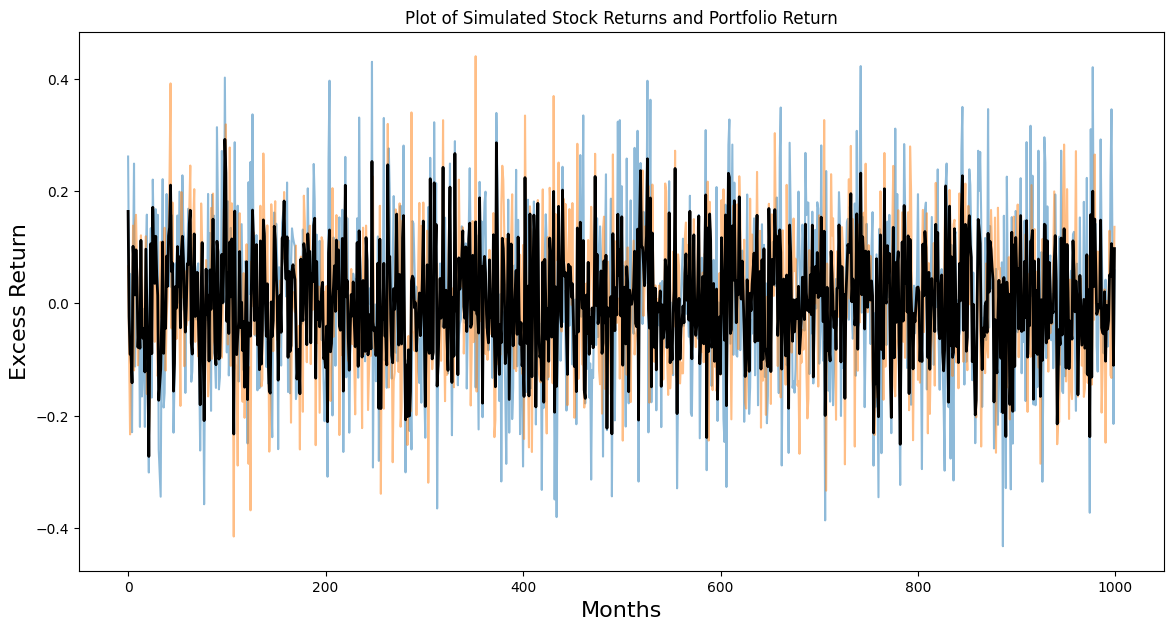

In [ ]:

plt.figure(figsize=(14, 7))
for i in range(N):
    plt.plot(excess_returns[:, i], alpha=0.5)

plt.plot(portfolio_returns, color='black', linewidth=2)
plt.title('Plot of Simulated Stock Returns and Portfolio Return')
plt.xlabel('Months', fontsize='16')
plt.ylabel('Excess Return', fontsize='16')
plt.show()


Calculate the Variance of the Portfolio Return
Here we calculate the variance of the portfolio return in two ways. First we simply use the NumPy variance function. We then calcaute this variance using the idea that idiosyncratic variance has been diversified away. The variance of the portfolio is


where
 is the beta of the portfolio relative to the tangent portfolio. The inner-product portfolio rule applies to portfolio betas, implying that the beta of the portfolio is an inner-product of individual asset betas and portfolio weights. The important idea to understand is that with many stocks,
 is essentially zero. Idiosyncratic risk gets diversifed away when there are many stocks in the portfolio.

In [ ]:
# Estimate portfolio beta
beta_pT = np.cov(portfolio_returns, T_returns, ddof=0)[0,1] / np.var(T_returns)
print("Portfolio Beta:", beta_pT)

# Portfolio variance
portfolio_variance = np.var(portfolio_returns)
print("Portfolio Variance:", portfolio_variance)

# Systematic risk
var_T_sim = np.var(T_returns)
portfolio_systematic_risk = (beta_pT**2) * var_T_sim
print("Systematic Risk:", portfolio_systematic_risk)

# Idiosyncratic risk
portfolio_idiosyncratic_risk = portfolio_variance - portfolio_systematic_risk
print("Idiosyncratic Risk:", portfolio_idiosyncratic_risk)

Portfolio Beta: 0.37267164652011747
Portfolio Variance: 0.009484470695019556
Systematic Risk: 0.0006140492282531627
Idiosyncratic Risk: 0.008870421466766393
